# Iteración V3: Deep Learning (LSTM)

Las Redes Neuronales Recurrentes, específicamente las **LSTM (Long Short-Term Memory)**, son excelentes para captar patrones secuenciales a largo plazo. Aunque solemos requerir enormes cantidades de datos para entrenar redes neuronales profundas (y aquí solo tenemos unos años mensuales), es un experimento de alto nivel muy interesante para ver si la red es capaz de aprender la relación que tienen los ingresos pasados con los gastos futuros sin decírselo de forma totalmente explícita.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Ocultar warnings de TensorFlow
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

### 1. Carga y Normalización (MinMax)
Las redes neuronales son muy sensibles a la escala de los datos. Necesitamos reducir todos los valores monetarios a un rango entre 0 y 1.

In [2]:
# Cargar datos
file_path = '../data/raw/db_orig.csv'
df = pd.read_csv(file_path)

df['Amount'] = df['Amount'].str.replace('€', '', regex=False).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
df['Amount'] = pd.to_numeric(df['Amount'])
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df['Month_End'] = df['Date'].dt.to_period('M').dt.to_timestamp('M')
monthly = df.groupby(['Month_End', 'Type'])['Amount'].sum().unstack(fill_value=0).reset_index()

if 'Expenses' not in monthly.columns: monthly['Expenses'] = 0
if 'Income' not in monthly.columns: monthly['Income'] = 0

ml_df = monthly.copy().sort_values('Month_End')

# Escaladores independientes para poder "des-escalar" las predicciones luego
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# Preparamos características (Entrada: Ingresos y Gastos Históricos)
scaled_features = scaler_X.fit_transform(ml_df[['Income', 'Expenses']]) 
scaled_target = scaler_y.fit_transform(ml_df[['Expenses']])

### 2. Creación de Secuencias 3D (Ventanas de Tiempo)
A diferencia de XGBoost donde la entrada es un vector plano `[Ingreso_Lag_1, Gastos_Lag_1]`, una LSTM espera datos en 3D: `[Nº_Muestras, Pasos_De_Tiempo, Nº_Características]`.
Le diremos: Toma los **3 últimos meses completos (Ingresos y Gastos)** para predecir el Gasto del **mes actual**.

In [3]:
def create_sequences(features, target, time_steps):
    X_seq, y_seq = [], []
    for i in range(len(features) - time_steps):
        X_seq.append(features[i:(i + time_steps)]) # Los últimos 'time_steps' meses
        y_seq.append(target[i + time_steps])     # El gasto del mes que queremos predecir
    return np.array(X_seq), np.array(y_seq)

TIME_STEPS = 3 # Ventana de tiempo (Lookback de 3 meses)

X_seq, y_seq = create_sequences(scaled_features, scaled_target, TIME_STEPS)
print(f"Forma de X (Entrada LSTM): {X_seq.shape} -> (Muestras, Meses_Previos, Features)")
print(f"Forma de y (Salida): {y_seq.shape}")

Forma de X (Entrada LSTM): (51, 3, 2) -> (Muestras, Meses_Previos, Features)
Forma de y (Salida): (51, 1)


### 3. División Entrenamiento/Prueba y Construcción de la Red Neuronal

In [4]:
# División 80/20 respetando el tiempo
split_idx = int(len(X_seq) * 0.8)
X_train, y_train = X_seq[:split_idx], y_seq[:split_idx]
X_test,  y_test  = X_seq[split_idx:], y_seq[split_idx:]

# Arquitectura del modelo LSTM
model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dropout(0.2), # Apagar el 20% de las neuronas aleatoriamente para evitar sobre-aprender los datos chicos
    Dense(25, activation='relu'),
    Dense(1) # Salida única (Gasto predicho en escala 0-1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,901 (46.49 KB)

 Trainable params: 11,901 (46.49 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Entrenamiento

In [5]:
# Entrenar el modelo con EarlyStopping para evitar Overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(X_train, y_train, 
                    epochs=150, 
                    batch_size=4, 
                    validation_data=(X_test, y_test), 
                    callbacks=[early_stopping], 
                    verbose=0) # verbose=0 para no llenar el notebook de texto
print("Entrenamiento Completado.")

Entrenamiento Completado.


### 5. Evaluación

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step

LSTM - MAE Final: 260.23€
LSTM - RMSE Final: 343.41€


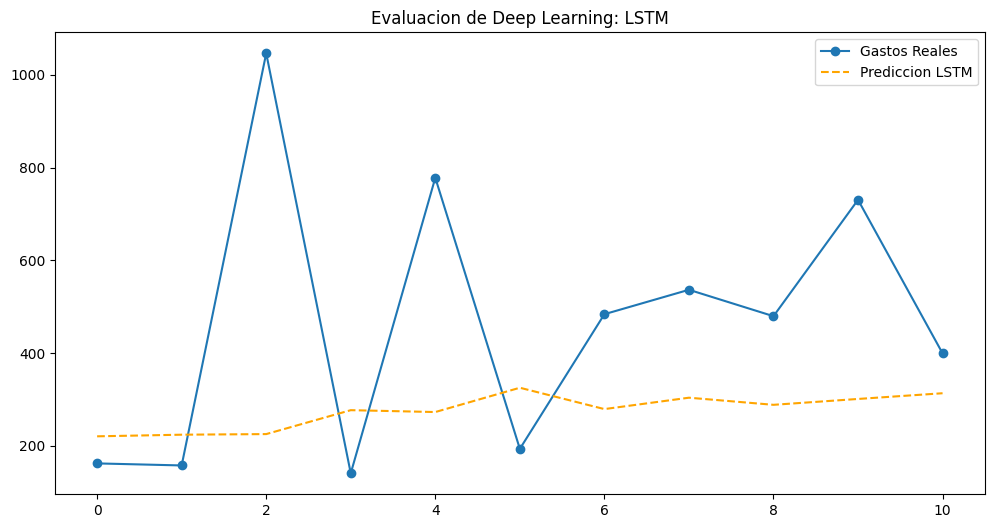

In [6]:
# Predecir datos de Test
predictions_scaled = model.predict(X_test)

# Revertir la normalización a la moneda original (€)
predictions_real = scaler_y.inverse_transform(predictions_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

# Métricas
mae = mean_absolute_error(y_test_real, predictions_real)
rmse = np.sqrt(mean_squared_error(y_test_real, predictions_real))

print(f"\nLSTM - MAE Final: {mae:.2f}€")
print(f"LSTM - RMSE Final: {rmse:.2f}€")

plt.figure(figsize=(12,6))
plt.plot(y_test_real, label='Gastos Reales', marker='o')
plt.plot(predictions_real, label='Prediccion LSTM', color='orange', linestyle='--')
plt.title('Evaluacion de Deep Learning: LSTM')
plt.legend()
plt.show()